# Reproduction du modele Quintic SV, version 2 detaillee

Cette version montre les calculs intermediaires. La premiere version du notebook reste intacte ; ici on ouvre la boite noire pour voir comment les courbes sont fabriquees.

## Ce qu'on va faire

On suit le cas `H` constant avec courbe spline, c'est celui des Figures 1 et 2 du papier. Puis on refait le calcul VIX plus explicitement.

Idee generale :

1. simuler le facteur gaussien `X_t` ;
2. construire le polynome `p(X_t)` ;
3. construire la volatilite instantanee `sigma_t` ;
4. pricer les calls SPX ;
5. pricer les calls VIX ;
6. tracer les courbes, puis superposer un pseudo-marche simule.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if not (ROOT / 'quintic_sv').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from quintic_sv.configs import paper_constant_h_spline_scenario
from quintic_sv.curves import evaluate_spline_forward_curve
from quintic_sv.market import add_synthetic_market_to_spx, add_synthetic_market_to_vix, simulate_forward_curve_comparison
from quintic_sv.model import normalization_variance, simulate_xt_grid_constant_h
from quintic_sv.plots import plot_forward_curve_comparison, plot_joint_smiles
from quintic_sv.pricing import (
    _control_variate_prices,
    _gauss_legendre,
    _gaussian_density,
    _integrated_beta_polynomial,
    price_spx_smile_constant_h_spline,
)
from quintic_sv.black import implied_volatility_vector
from quintic_sv.utils import VIX_WINDOW_YEARS, generate_antithetic_normals, horner_vector, spx_log_moneyness_range

plt.rcParams['figure.figsize'] = (8, 3)
scenario = paper_constant_h_spline_scenario()
coeffs = scenario.params.coefficients()
scenario

SplineScenario(name='figure_1_and_2', spot=100.0, params=ConstantHParams(rho=-0.6842593, H=-0.03583785, eps=0.019230769230769232, alpha0=0.59069477, alpha1=0.99999991, alpha3=0.28927803, alpha5=0.05491437), forward_node_times=array([0.        , 0.02601012, 0.03696174, 0.05065128, 0.06297186,
       0.07529244, 0.08898198, 0.09993361, 0.10540942, 0.11636105,
       0.1355264 , 0.16427442, 0.21218779, 0.25736326]), forward_node_values=array([0.00950134, 0.00799541, 0.00514354, 0.01079057, 0.02396814,
       0.00793446, 0.01301627, 0.02776016, 0.00222057, 0.01965447,
       0.01085834, 0.02437202, 0.01278166, 0.01881186]), spx_maturities=array([0.03011698, 0.08213721, 0.18343977, 0.24093582]), vix_maturities=array([0.02464116, 0.06297186, 0.08213721, 0.15879861]), spx_n_steps=800, spx_n_sims=20000, vix_n_steps=200, quadrature_degree=400, seed=42, market_seed=1701, vix_log_moneyness_min=-0.1, vix_log_moneyness_max=1.0, vix_num_strikes=50)

## 1. Parametres d'entree

Formule utilisee :

$$\sigma_t = \sqrt{\xi_0(t)} \frac{p(X_t)}{\sqrt{\mathbb E[p(X_t)^2]}}$$

avec

$$p(x)=\alpha_0 + \alpha_1 x + \alpha_3 x^3 + \alpha_5 x^5$$

Entrees ici : `rho`, `H`, `eps`, les coefficients `alpha`, et les noeuds de la courbe `xi_0`.

Sortie plus tard : une trajectoire de volatilite `sigma_t`.

In [2]:
spot = scenario.spot
maturity = float(scenario.spx_maturities[1])  # 30 jours environ
n_steps = 120
n_sims = 1200
normals = generate_antithetic_normals(n_steps, n_sims, scenario.seed)

print('spot =', spot)
print('maturity =', maturity)
print('rho =', scenario.params.rho)
print('H =', scenario.params.H)
print('eps =', scenario.params.eps)
print('coeffs =', coeffs)

spot = 100.0
maturity = 0.08213721
rho = -0.6842593
H = -0.03583785
eps = 0.019230769230769232
coeffs = [0.59069477 0.99999991 0.         0.28927803 0.         0.05491437]


## 2. Simulation du facteur `X_t`

Formule utilisee :

$$dX_t = -(1/2-H)\varepsilon^{-1} X_t dt + \varepsilon^{H-1/2} dW_t$$

Entrees : `H`, `eps`, la maturite et des gaussiennes standard.

Sorties : la grille de temps, les trajectoires `X_t`, et l'ecart-type theorique de `X_t` a chaque date.

Utilite : `X_t` est le seul facteur qui pilote toute la volatilite.

In [3]:
times, xt_paths, std_x = simulate_xt_grid_constant_h(scenario.params.H, scenario.params.eps, maturity, normals)

print('shape times   =', times.shape)
print('shape X paths =', xt_paths.shape)
print('shape std_x   =', std_x.shape)
print('premieres valeurs std_x =', np.round(std_x[:8], 6))
print('extrait trajectoire X_t =', np.round(xt_paths[:8, 0], 6))

shape times   = (120,)
shape X paths = (120, 2400)
shape std_x   = (120,)
premieres valeurs std_x = [0.       0.215303 0.301622 0.36596  0.418653 0.463752 0.503361 0.538744]
extrait trajectoire X_t = [ 0.        0.065607 -0.22038  -0.312257 -0.097892 -0.090603 -0.040423
  0.142645]


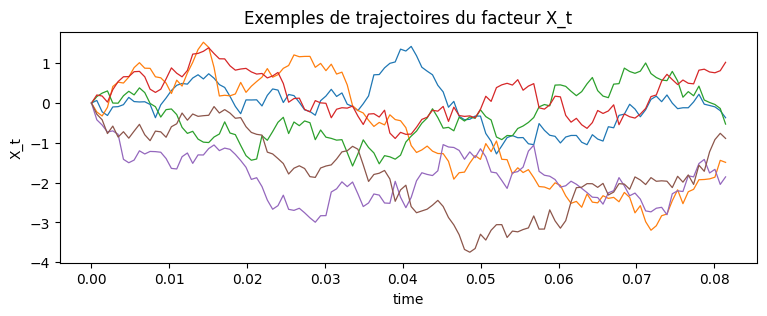

In [4]:
plt.figure(figsize=(9, 3))
for idx in range(6):
    plt.plot(times, xt_paths[:, idx], linewidth=0.9)
plt.title('Exemples de trajectoires du facteur X_t')
plt.xlabel('time')
plt.ylabel('X_t')
plt.show()

## 3. Calcul du polynome `p(X_t)` et de la normalisation

Formule utilisee :

$$p(X_t)=\alpha_0 + \alpha_1 X_t + \alpha_3 X_t^3 + \alpha_5 X_t^5$$

et

$$\mathbb E[p(X_t)^2]$$

Entrees : les coefficients `alpha` et les trajectoires `X_t`.

Sorties : la valeur brute `p(X_t)` et la normalisation theorique.

Utilite : cette normalisation permet a `xi_0(t)` de jouer le role de courbe de variance forward.

In [5]:
p_xt = horner_vector(coeffs[::-1], xt_paths)
normal_var = normalization_variance(coeffs, std_x)

print('shape p(X_t) =', p_xt.shape)
print('shape E[p(X_t)^2] =', normal_var.shape)
print('extrait p(X_t) =', np.round(p_xt[:8, 0], 6))
print('extrait E[p(X_t)^2] =', np.round(normal_var[:8], 6))

shape p(X_t) = (120, 2400)
shape E[p(X_t)^2] = (120,)
extrait p(X_t) = [0.590695 0.656383 0.36719  0.269467 0.492531 0.499876 0.550252 0.734183]
extrait E[p(X_t)^2] = [0.34892  0.399311 0.456694 0.522147 0.596757 0.681589 0.777657 0.885899]


## 4. Construction de la courbe `xi_0(t)` et de la volatilite `sigma_t`

Formule utilisee :

$$\sigma_t = \sqrt{\xi_0(t)} \frac{p(X_t)}{\sqrt{\mathbb E[p(X_t)^2]}}$$

Entrees : les noeuds spline de `xi_0`, `p(X_t)` et `E[p(X_t)^2]`.

Sortie : une trajectoire de volatilite instantanee pour chaque simulation.

Utilite : c'est l'objet directement injecte dans le pricing SPX.

In [6]:
forward_curve = evaluate_spline_forward_curve(times, scenario.forward_node_times, scenario.forward_node_values)
volatility = np.sqrt(forward_curve)[:, None] * p_xt / np.sqrt(normal_var)[:, None]

print('shape xi_0(t) =', forward_curve.shape)
print('shape sigma_t =', volatility.shape)
print('extrait xi_0(t) =', np.round(forward_curve[:8], 6))
print('extrait sigma_t =', np.round(volatility[:8, 0], 6))

shape xi_0(t) = (120,)
shape sigma_t = (120, 2400)
extrait xi_0(t) = [0.009501 0.010117 0.010694 0.01123  0.011722 0.012168 0.012568 0.012919]
extrait sigma_t = [0.097475 0.104478 0.056189 0.039518 0.069028 0.06679  0.069951 0.088661]


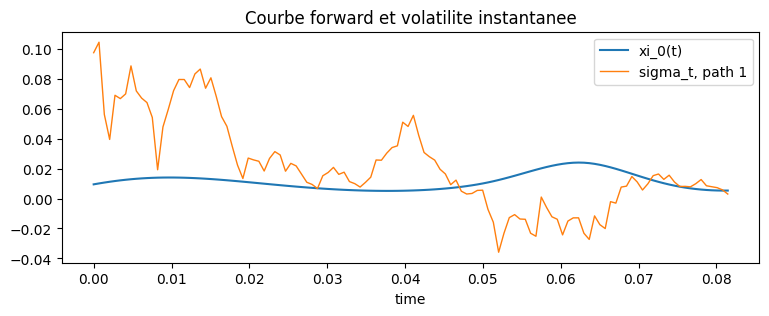

In [7]:
plt.figure(figsize=(9, 3))
plt.plot(times, forward_curve, label='xi_0(t)', linewidth=1.5)
plt.plot(times, volatility[:, 0], label='sigma_t, path 1', linewidth=1.0)
plt.title('Courbe forward et volatilite instantanee')
plt.xlabel('time')
plt.legend()
plt.show()

## 5. Pricing SPX

Le papier utilise Monte Carlo pour SPX, avec antithetiques et control variate.

Entrees : `sigma_t`, `rho`, `S_0`, les strikes, la maturite et les gaussiennes.

Sorties : prix de calls SPX, puis volatilites implicites.

Utilite : produire les smiles SPX du papier.

In [8]:
lm_min, lm_max = spx_log_moneyness_range(maturity)
spx_strikes = np.exp(np.linspace(lm_min, lm_max, 20)) * spot

spx_prices, spx_conf_scale = _control_variate_prices(
    scenario.params.rho,
    maturity,
    spot,
    spx_strikes,
    volatility,
    normals,
    n_sims,
)
spx_iv = implied_volatility_vector(spx_prices, spot, spx_strikes, maturity)

print('extrait prix calls SPX =', np.round(spx_prices[:6], 6))
print('extrait IV SPX =', np.round(spx_iv[:6], 6))

extrait prix calls SPX = [22.135406 20.898695 19.642868 18.36776  17.073238 15.759224]
extrait IV SPX = [0.343756 0.330212 0.316468 0.30247  0.28816  0.273484]


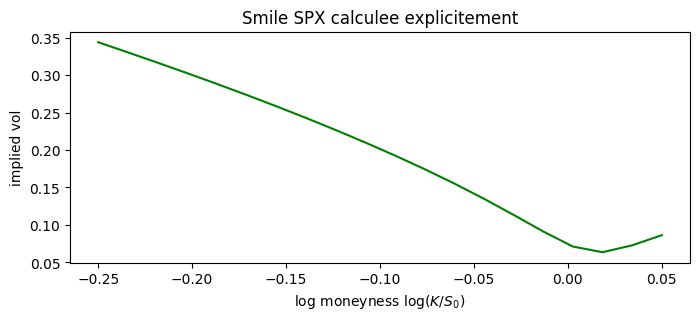

In [9]:
plt.figure(figsize=(8, 3))
plt.plot(np.log(spx_strikes / spot), spx_iv, color='green')
plt.title('Smile SPX calculee explicitement')
plt.xlabel(r'log moneyness $\log(K/S_0)$')
plt.ylabel('implied vol')
plt.show()

## 6. Pricing VIX

Formule utilisee :

$$\mathrm{VIX}_T^2 = \frac{100^2}{\Delta} \int_T^{T+\Delta} \xi_T(u) \, du$$

Dans ce modele, `VIX_T^2` devient un polynome en `X_T` avec des coefficients `beta_i`.

Entrees : `H`, `eps`, `alpha`, la courbe `xi_0`, la maturite `T` et la fenetre VIX `Delta = 30/360`.

Sorties : future VIX, prix des calls VIX, puis volatilites implicites VIX.

Utilite : produire les smiles VIX du papier.

In [10]:
vix_maturity = float(scenario.vix_maturities[1])  # environ 23 jours
delta = VIX_WINDOW_YEARS
u_grid = np.linspace(vix_maturity, vix_maturity + delta, scenario.vix_n_steps + 1)
dt = delta / scenario.vix_n_steps

kappa_tilde = (0.5 - scenario.params.H) / scenario.params.eps
eta_tilde = scenario.params.eps ** (scenario.params.H - 0.5)
exp_det = np.exp(-kappa_tilde * (u_grid - vix_maturity))
std_g = eta_tilde * np.sqrt(1.0 / (2.0 * kappa_tilde) * (1.0 - np.exp(-2.0 * kappa_tilde * (u_grid - vix_maturity))))
std_x_u = eta_tilde * np.sqrt(1.0 / (2.0 * kappa_tilde) * (1.0 - np.exp(-2.0 * kappa_tilde * u_grid)))
std_x_t = eta_tilde * np.sqrt(1.0 / (2.0 * kappa_tilde) * (1.0 - np.exp(-2.0 * kappa_tilde * vix_maturity)))

cauchy_product = np.convolve(coeffs, coeffs)
normal_var_u = normalization_variance(coeffs, std_x_u)
forward_curve_u = evaluate_spline_forward_curve(u_grid, scenario.forward_node_times, scenario.forward_node_values)
beta_integrated = _integrated_beta_polynomial(cauchy_product, exp_det, std_g, forward_curve_u, normal_var_u, dt)

print('extrait beta_i =', np.round(beta_integrated[:6], 6))
print('std_X_T =', round(float(std_x_t), 6))

extrait beta_i = [7.72e-04 5.20e-05 2.10e-04 5.00e-06 2.50e-05 0.00e+00]
std_X_T = 1.09615


In [11]:
y_nodes, y_weights = _gauss_legendre(-8.0, 8.0, 250)
density = _gaussian_density(y_nodes)
vix_values = np.sqrt(np.maximum(horner_vector(beta_integrated[::-1], std_x_t * y_nodes) / delta, 0.0))
vix_future = np.sum(density * vix_values * y_weights)
vix_strike_perc = np.exp(np.linspace(-0.1, 1.0, 25))
vix_strikes = vix_future * vix_strike_perc
vix_prices = np.sum(density[None, :] * np.maximum(vix_values[None, :] - vix_strikes[:, None], 0.0) * y_weights[None, :], axis=1)
vix_iv = implied_volatility_vector(vix_prices, vix_future, vix_strikes, vix_maturity)

print('future VIX =', round(float(100.0 * vix_future), 6))
print('extrait prix calls VIX =', np.round(100.0 * vix_prices[:6], 6))
print('extrait IV VIX =', np.round(vix_iv[:6], 6))

future VIX = 11.67046
extrait prix calls VIX = [1.47591  1.279139 1.114464 0.97536  0.855518 0.75218 ]
extrait IV VIX = [0.721534 0.827663 0.917664 0.997963 1.070314 1.137155]


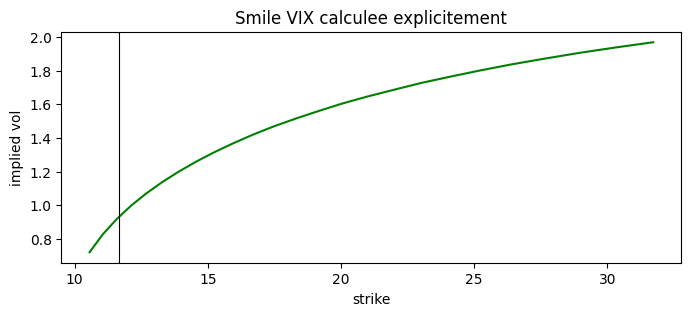

In [12]:
plt.figure(figsize=(8, 3))
plt.plot(100.0 * vix_strikes, vix_iv, color='green')
plt.axvline(100.0 * vix_future, color='black', linewidth=0.8)
plt.title('Smile VIX calculee explicitement')
plt.xlabel('strike')
plt.ylabel('implied vol')
plt.show()

## 7. Passage aux courbes finales du papier

Ici on repasse par les fonctions haut niveau du projet. Elles font exactement les memes types de calculs, mais pour toutes les maturites d'une figure.

Ensuite on ajoute un pseudo-marche simule : points bleu/rouge pour imiter bid/ask, et une courbe `xi_0` de marche synthetique pour illustrer la partie "donnees externes" absente.

In [13]:
smile_full = price_spx_smile_constant_h_spline(
    scenario.params.rho,
    scenario.params.H,
    scenario.params.eps,
    maturity,
    coeffs,
    spot,
    spx_strikes,
    scenario.forward_node_times,
    scenario.forward_node_values,
    normals,
    n_sims,
)
smile_full = add_synthetic_market_to_spx(smile_full, scenario.market_seed)
curve_compare = simulate_forward_curve_comparison(scenario.forward_node_times, scenario.forward_node_values, scenario.market_seed + 1)

print('shape smile_full model_iv =', smile_full.model_iv.shape)
print('shape pseudo market bid   =', smile_full.market_bid_iv.shape)

shape smile_full model_iv = (20,)
shape pseudo market bid   = (20,)


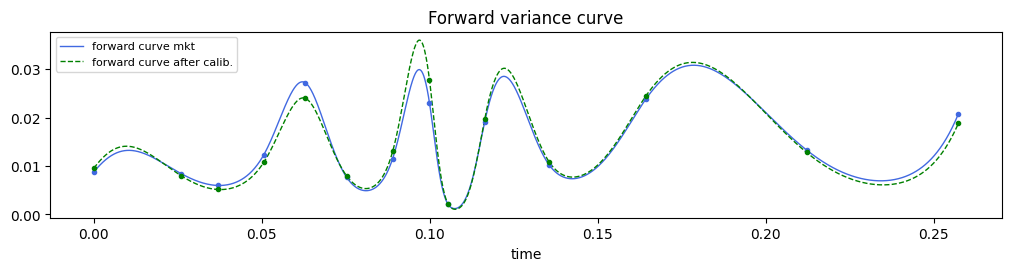

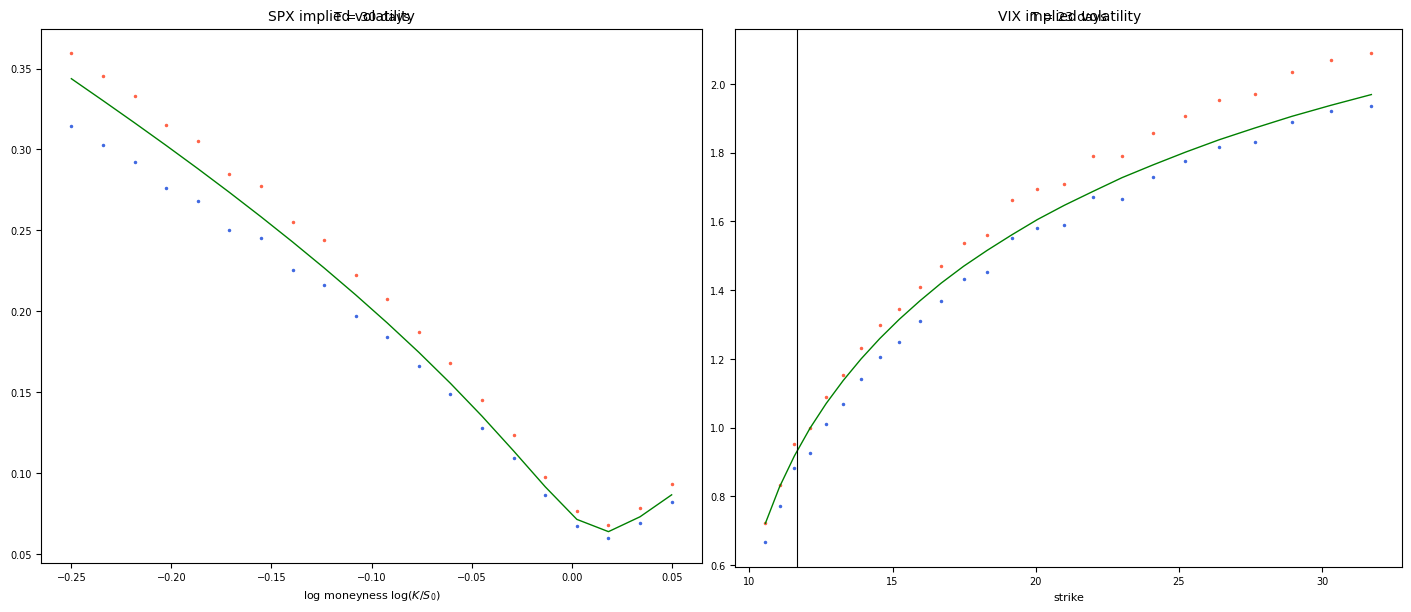

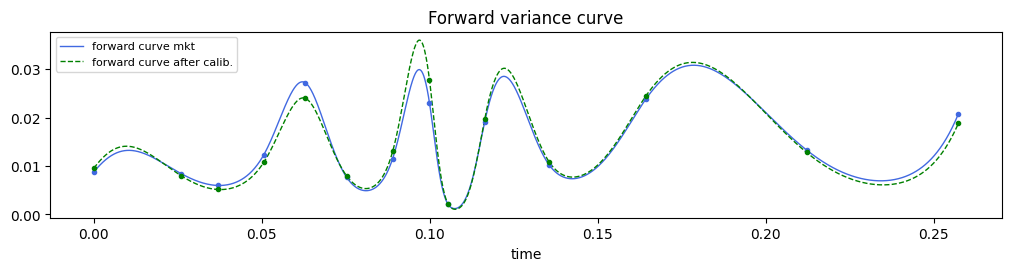

In [14]:
from quintic_sv.pricing import price_vix_smile_constant_h_spline

vix_smile_full = price_vix_smile_constant_h_spline(
    scenario.params.H,
    scenario.params.eps,
    vix_maturity,
    coeffs,
    vix_strike_perc,
    scenario.forward_node_times,
    scenario.forward_node_values,
    quadrature_degree=250,
    n_steps=scenario.vix_n_steps,
)
vix_smile_full = add_synthetic_market_to_vix(vix_smile_full, scenario.market_seed + 2)

fig_joint = plot_joint_smiles([smile_full], [vix_smile_full], orientation='side_by_side')
fig_curve = plot_forward_curve_comparison(curve_compare)
fig_joint
fig_curve

## A retenir

- le notebook V1 montrait bien les vraies courbes, mais en mode pipeline ;
- ce notebook V2 montre les objets intermediaires qui fabriquent ces courbes ;
- les lignes vertes viennent du vrai calcul du modele ;
- les points bleu/rouge et la courbe "market" sont simules ici parce qu'on n'a pas les donnees CBOE.